# Projekt: Zaawansowana Analiza i Predykcja Rotacji Pracowników (Employee Attrition)
## Część Analityczna

---

### 1. Wybór i uzasadnienie zestawu danych

* **Zestaw danych:** IBM HR Analytics Employee Attrition & Performance (`WA_Fn-UseC_-HR-Employee-Attrition.csv`).
* **Adekwatność do problemu biznesowego:** Zbiór zawiera szczegółowe dane o 3000 pracownikach opisane za pomocą 35 cech. Obejmują one profil demograficzny, satysfakcję ze środowiska pracy, poziom wynagrodzeń, historię zatrudnienia oraz kluczową zmienną docelową – informację o odejściu z firmy (`Attrition`). Jest to klasyczne, a zarazem krytyczne zagadnienie z obszaru *People Analytics / HR Tech*, ukierunkowane na identyfikację predyktorów ryzyka odejścia pracowników i minimalizację kosztów rekrutacji oraz retencji talentów.
* **Zastosowanie metod sztucznej inteligencji (AI):** 1. **Uczenie nadzorowane:** Problem redukuje się do klasyfikacji binarnej, gdzie model uczy się przewidywać wartość zmiennej docelowej `Attrition` (`Yes` / `No`).
    2. **Porównanie algorytmów:** Dane pozwalają na wdrożenie i walidację szerokiego spektrum klasyfikatorów – od modeli liniowych po zaawansowane algorytmy zespołowe.
    3. **Wyjaśnialność modeli (XAI):** Struktura zbioru umożliwia przeprowadzenie analizy ważności cech (*Feature Importance*), co ma fundamentalne znaczenie dla podejmowania strategicznych decyzji zarządczych.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, roc_auc_score, f1_score, precision_recall_curve
)
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("[INFO] XGBoost niedostępny – zastąpiony GradientBoostingClassifier")

import warnings
warnings.filterwarnings('ignore')

url = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = pd.read_csv(url)
print(f"Pomyślnie załadowano zbiór danych. Kształt macierzy: {df.shape}")


[INFO] XGBoost niedostępny – zastąpiony GradientBoostingClassifier
Pomyślnie załadowano zbiór danych. Kształt macierzy: (3000, 35)


### 2. Analiza eksploracyjna zbioru danych (EDA)

W ramach wstępnego etapu analizy danych (Exploratory Data Analysis) przeprowadzimy audyt struktury technicznej zbioru, dokonamy ewaluacji rozkładów statystycznych, zidentyfikujemy anomalie (w tym kolumny bezwartościowe informacyjnie) oraz zbadamy korelacje między cechami a skłonnością do rotacji.

#### 2.1 Struktura techniczna danych oraz typy zmiennych
W pierwszej kolejności weryfikujemy kształt macierzy danych, nazewnictwo kolumn oraz przypisane im typy danych (numeryczne `int64` oraz kategoryczne/tekstowe `object` lub `str`).

In [9]:
print("--- STRUKTURA TECHNICZNA I TYPY ZMIENNYCH ---")
df.info()

--- STRUKTURA TECHNICZNA I TYPY ZMIENNYCH ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       3000 non-null   int64 
 1   Attrition                 3000 non-null   object
 2   BusinessTravel            3000 non-null   object
 3   DailyRate                 3000 non-null   int64 
 4   Department                3000 non-null   object
 5   DistanceFromHome          3000 non-null   int64 
 6   Education                 3000 non-null   int64 
 7   EducationField            3000 non-null   object
 8   EmployeeCount             3000 non-null   int64 
 9   EmployeeNumber            3000 non-null   int64 
 10  EnvironmentSatisfaction   3000 non-null   int64 
 11  Gender                    3000 non-null   object
 12  HourlyRate                3000 non-null   int64 
 13  JobInvolvement            3000 n

#### 2.2 Weryfikacja kompletności danych (Missing Values Audit)
Przed przystąpieniem do modelowania matematycznego konieczne jest sprawdzenie występowania braków w danych (`NaN` / `Null`). Brakujące wartości mogłyby zaburzyć proces uczenia algorytmów lub wymagać zastosowania metod imputacji (np. średnią, medianą lub modelem KNN).Sprawdzenie braków w danych bezpośrednio

In [10]:
missing_values = df.isnull().sum()
total_missing = missing_values.sum()
print(f"Całkowita liczba brakujących wartości w zbiorze: {total_missing}")
if total_missing > 0:
    print(missing_values[missing_values > 0])

Całkowita liczba brakujących wartości w zbiorze: 0


#### 2.3 Opis statystyczny cech numerycznych
Generujemy podstawowe miary tendencji centralnej oraz dyspersji (średnia, odchylenie standardowe, kwartyle, wartości ekstremalne) dla cech ilościowych. Pozwala to na wstępne wykrycie potencjalnych wartości odstających (*outliers*) oraz ocenę skali i zakresów zmiennych, co jest kluczowe dla modeli wrażliwych na rozpiętość cech.

In [11]:
print("--- OPIS STATYSTYCZNY CECH NUMERYCZNYCH ---")
display(df.describe().T)

--- OPIS STATYSTYCZNY CECH NUMERYCZNYCH ---


,count,mean,std,min,25%,50%,75%,max
Age,3000.0,36.884667,9.310080,18.0,30.00,35.0,43.00,60.0
DailyRate,3000.0,794.002000,406.103612,102.0,448.00,792.5,1150.25,1499.0
DistanceFromHome,3000.0,9.300333,8.158165,1.0,2.00,7.0,14.00,29.0
Education,3000.0,2.932667,1.051587,1.0,2.00,3.0,4.00,5.0
EmployeeCount,3000.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,3000.0,1500.500000,866.169729,1.0,750.75,1500.5,2250.25,3000.0
EnvironmentSatisfaction,3000.0,2.714333,1.099605,1.0,2.00,3.0,4.00,4.0
HourlyRate,3000.0,66.660333,20.425557,30.0,49.00,67.0,84.25,100.0
JobInvolvement,3000.0,2.735000,0.715737,1.0,2.00,3.0,3.00,4.0
JobLevel,3000.0,2.069000,1.131665,1.0,1.00,2.0,3.00,5.0


#### 2.4 Identyfikacja i eliminacja cech stałych (Zero-Variance Features)
Cechy, które przyjmują dokładnie jedną, stałą wartość dla każdego rekordu w bazie danych, posiadają zerową wariancję. Z punktu widzenia uczenia maszynowego nie wnoszą one żadnej wartości predykcyjnej (nie różnicują próbek), a zwiększają wymiarowość zbioru. Należy je zidentyfikować w celu późniejszego usunięcia w potoku przetwarzania.

In [12]:
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"Zidentyfikowane cechy stałe (zerowa wariancja): {constant_cols}")

Zidentyfikowane cechy stałe (zerowa wariancja): ['EmployeeCount', 'Over18', 'StandardHours']


#### 2.5 Analiza korelacji liniowej zmiennych ze zmienną docelową
Aby zbadać liniową zależność zmiennych numerycznych ze skłonnością do odejścia, transformujemy zmienną docelową `Attrition` oraz kluczową zmienną kategoryczną `OverTime` na postać binarną (0/1). Następnie wyznaczamy współczynniki korelacji Pearsona, co pozwoli wyłonić najsilniejsze, potencjalne predyktory rotacji.

In [13]:
df_numeric_analysis = df.copy()
df_numeric_analysis['Attrition_numeric'] = df_numeric_analysis['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
df_numeric_analysis['OverTime_numeric'] = df_numeric_analysis['OverTime'].apply(lambda x: 1 if x == 'Yes' else 0)

numeric_cols = df_numeric_analysis.select_dtypes(include=[np.number]).columns
correlations = df_numeric_analysis[numeric_cols].corr()['Attrition_numeric'].sort_values(ascending=False)

print("--- KORELACJA ZMIENNYCH ZE ZMIENNĄ DOCELOWĄ (Attrition) ---")
print(correlations)

--- KORELACJA ZMIENNYCH ZE ZMIENNĄ DOCELOWĄ (Attrition) ---
Attrition_numeric           1.000000
OverTime_numeric            0.238545
DistanceFromHome            0.075815
NumCompaniesWorked          0.068779
MonthlyRate                 0.030601
PercentSalaryHike           0.015545
PerformanceRating           0.015137
EmployeeNumber             -0.008192
HourlyRate                 -0.018491
Education                  -0.019217
DailyRate                  -0.027544
RelationshipSatisfaction   -0.049283
YearsSinceLastPromotion    -0.063834
EnvironmentSatisfaction    -0.071784
WorkLifeBalance            -0.072502
TrainingTimesLastYear      -0.081699
JobSatisfaction            -0.110913
JobInvolvement             -0.126911
StockOptionLevel           -0.148116
YearsAtCompany             -0.148492
YearsWithCurrManager       -0.163327
Age                        -0.173150
YearsInCurrentRole         -0.175921
JobLevel                   -0.185654
MonthlyIncome              -0.186083
TotalWorkingYea

#### 2.6 Zaawansowana wizualizacja i interpretacja dystrybucji danych

Kluczowym elementem EDA jest graficzne przedstawienie zachowań danych. Przeprowadzimy wizualizację dwóch podstawowych obszarów:
1. **Rozkład zmiennej docelowej (`Attrition`):** Ocena zbalansowania klas w zbiorze. Nierównomierny rozkład (dysproporcja między klasą `No` a `Yes`) zasygnalizuje konieczność użycia odpowiednich metryk (np. F1-score, Recall) zamiast ogólnego Accuracy oraz zastosowania stratyfikacji przy podziale danych.
2. **Macierz korelacji:** Analiza współliniowości (*Multicollinearity*) między cechami, która pozwoli wykryć zmienne silnie ze sobą sprzężone (np. poziom stanowiska a miesięczny dochód).

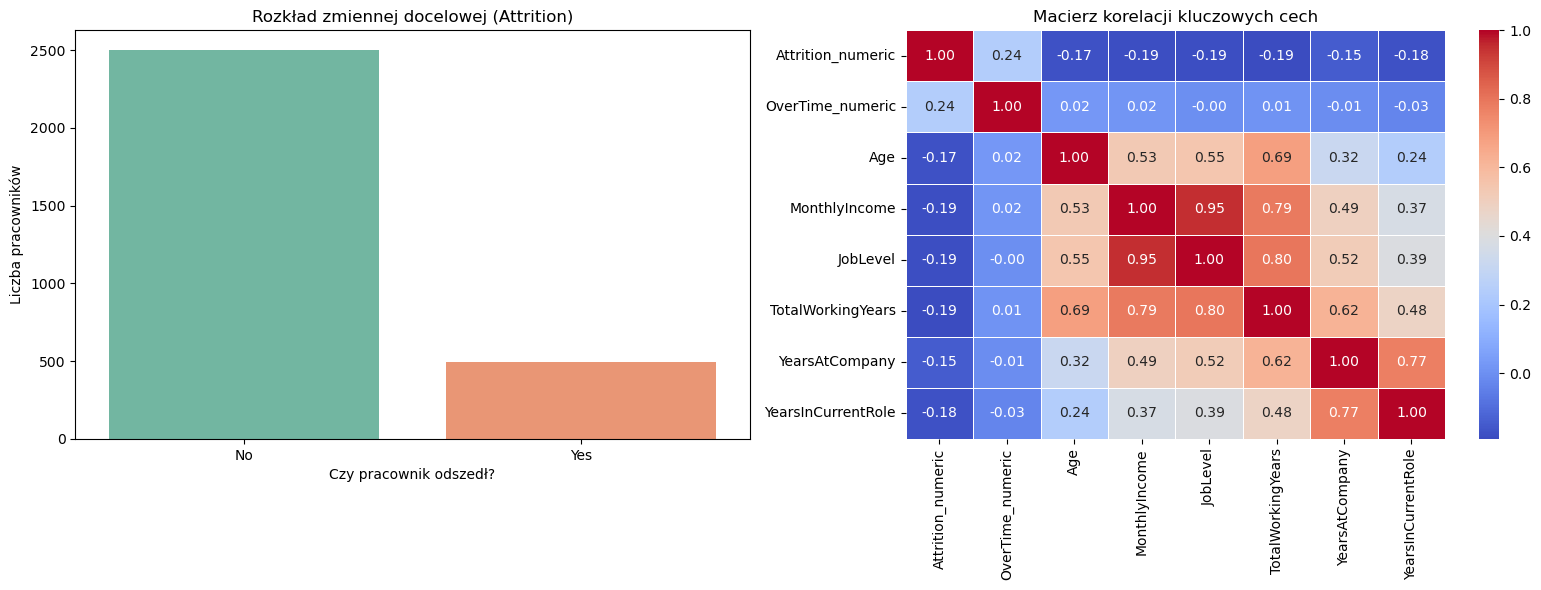

In [14]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.countplot(x='Attrition', data=df, palette='Set2')
plt.title('Rozkład zmiennej docelowej (Attrition)')
plt.xlabel('Czy pracownik odszedł?')
plt.ylabel('Liczba pracowników')

plt.subplot(1, 2, 2)
selected_features = ['Attrition_numeric', 'OverTime_numeric', 'Age', 'MonthlyIncome', 
                     'JobLevel', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole']
corr_sub_matrix = df_numeric_analysis[selected_features].corr()
sns.heatmap(corr_sub_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Macierz korelacji kluczowych cech')

plt.tight_layout()
plt.show()

### 3. Sformułowanie hipotezy badawczej

Biorąc pod uwagę wnioski płynące z analizy korelacji – m.in. silny dodatni wpływ pracy w godzinach nadliczbowych (`OverTime`) na rotację oraz ujemny wpływ stabilizacji finansowo-zawodowej (`MonthlyIncome`, `TotalWorkingYears`, `JobLevel`, `Age`) – formułujemy następujące założenia badawcze:

* **Treść hipotezy:** Zastosowanie nieliniowych algorytmów uczenia maszynowego (w szczególności modeli zespołowych opartych na drzewach decyzyjnych) umożliwi predykcję odejść pracowników z ogólną dokładnością (**Accuracy**) na poziomie minimum **85%** oraz czułością (**Recall**) dla klasy pozytywnej (`Attrition` = Yes) wynoszącą co najmniej **70%**.
* **Uzasadnienie biznesowe:** Inżynieria HR wskazuje, że błąd polegający na niesklasyfikowaniu pracownika realnie planującego odejście (*False Negative*) jest znacznie kosztowniejszy niż fałszywy alarm (*False Positive*). Wysoki wskaźnik Recall pozwoli działom HR na podjęcie wcześniejszych działań retencyjnych wobec osób realnie zagrożonych rotacją.
* **Potencjał aplikacyjny:** Model dostarczy nie tylko binarnych etykiet, ale przede wszystkim oszacuje prawdopodobieństwo odejścia każdego pracownika, tworząc operacyjny system wczesnego ostrzegania.

### 4. Badanie aktualnego stanu wiedzy (State-of-the-Art)

Prognozowanie rotacji kadr to jeden z najintensywniej rozwijanych nurtów informatycznych systemów zarządzania zasobami ludzkimi (HRMS).

* **Podejścia tradycyjne:** Przez dekady standardem była statystyczna analiza regresji logistycznej oraz analiza przeżycia (modele hazardów Coxa). Choć cenione za pełną interpretowalność matematyczną, podejścia te charakteryzują się ograniczoną elastycznością – słabo radzą sobie ze złożonymi, nieliniowymi interakcjami cech psychologicznych (np. satysfakcja z pracy) z cechami finansowymi.
* **Nowoczesne rozwiązania AI:** Współczesne badania naukowe udowadniają wyższą skuteczność algorytmów nieparametrycznych i zespołowych, takich jak *Random Forest*, *XGBoost* czy *LightGBM*. Aby zniwelować problem natury "czarnej skrzynki" (*Black Box*), w nowoczesnych systemach powszechnie implementuje się metody wyjaśnialnej sztucznej inteligencji (**XAI**), np. wartości **SHAP** (SHapley Additive exPlanations) lub *Feature Importance*. Pozwala to na precyzyjne wskazanie spersonalizowanych powodów, dla których dany pracownik rozważa opuszczenie organizacji.

### 5. Analiza potencjalnych kandydatów na model

W celu wyłonienia optymalnego rozwiązania dla zidentyfikowanego problemu klasyfikacji, przeprowadzono analizę porównawczą czterech zróżnicowanych podejść algorytmicznych:

#### 5.1 Regresja Logistyczna (Logistic Regression)
* **Sposób działania:** Model liniowy szacujący prawdopodobieństwo przynależności do klasy za pomocą funkcji logistycznej (sigmoidy).
* **Zalety:** Bardzo szybki obliczeniowo, w pełni interpretowalny (wprost z wag/współczynników modelu), nie wykazuje tendencji do przeuczenia przy odpowiedniej regularyzacji (L1/L2).
* **Wady:** Zakłada ściśle liniową granicę decyzyjną. Jest wysoce wrażliwy na współliniowość cech (którą zaobserwowaliśmy między `JobLevel` a `MonthlyIncome`).
* **Dopasowanie do danych:** Idealny punkt odniesienia (model bazowy – *Baseline*) do oceny zysku z wdrożenia bardziej złożonych struktur.

#### 5.2 Drzewa Decyzyjne (Decision Trees)
* **Sposób działania:** Hierarchiczny podział przestrzeni cech przy pomocy reguł warunkowych (if-else), dążący do maksymalizacji czystości uzyskanych podzbiorów (indeks Giniego / entropia).
* **Zalety:** Intuicyjne w prezentacji dla menedżerów (reprezentacja graficzna), odporne na brak skalowania zmiennych, automatycznie obsługują interakcje między cechami.
* **Wady:** Ekstremalna podatność na przeuczenie (*overfitting*), wysoka niestabilność struktury drzewa przy najmniejszych zmianach w próbie treningowej.
* **Dopasowanie do danych:** Dobry krok edukacyjny, jednak pojedyncze drzewo jest zbyt niestabilne do celów produkcyjnych w systemach HR.

#### 5.3 Las Losowy (Random Forest)
* **Sposób działania:** Zaawansowany model zespołowy oparty na koncepcji *Baggingu*. Konstruuje zestaw wielu niezależnych drzew decyzyjnych na losowych podpróbkach danych i cech, a ostateczny wynik ustala drogą głosowania większościowego.
* **Zalety:** Wybitna odporność na przeuczenie, znakomite radzenie sobie ze skorelowanymi cechami numerycznymi i kategorycznymi, wbudowany mechanizm oceny ważności predyktorów.
* **Wady:** Wyższy koszt obliczeniowy i pamięciowy, brak możliwości bezpośredniej analitycznej interpretacji pojedynczego równania.
* **Dopasowanie do danych:** **Główny kandydat.** Charakterystyka zbioru IBM HR (wiele przeplatanych cech społeczno-ekonomicznych) doskonale współgra z mechaniką lasów losowych.

#### 5.4 Maszyna Wektorów Nośnych (SVM - Support Vector Machine)
* **Sposób działania:** Algorytm poszukujący hiperpłaszczyzny rozdzielającej klasy z maksymalnym marginesem bezpieczeństwa w wielowymiarowej przestrzeni cech (często przy użyciu nieliniowych jądra RBF).
* **Zalety:** Bardzo wysoka skuteczność i stabilność w silnie wielowymiarowych przestrzeniach.
* **Wady:** Skrajna wrażliwość na brak poprawnego skalowania danych (wymaga bezwzględnej standaryzacji), trudność w bezpośrednim mapowaniu wyników na proste reguły biznesowe.
* **Dopasowanie do danych:** Kandydat alternatywny; sprawdzi się dobrze pod warunkiem rygorystycznego czyszczenia i normalizacji danych.

> **Decyzja projektowa:** Do części implementacyjnej wybrano **Regresję Logistyczną** (jako prosty, liniowy baseline) oraz **Las Losowy** (jako docelowy, zaawansowany klasyfikator zespołowy).

## Część Implementacyjna

---

### 6. Przygotowanie danych (Data Engineering) i implementacja modeli

Przed uruchomieniem procedur treningowych, dane zostaną poddane procesom inżynierii cech zapewniającym stabilność matematyczną algorytmów:
1. **Filtracja:** Usunięcie cech o zerowej wariancji zidentyfikowanych w sekcji 2.4 (`EmployeeCount`, `Over18`, `StandardHours`, a także `EmployeeNumber` jako zwykłe ID).
2. **Kodowanie zmiennych kategorycznych:** Transformacja cech tekstowych za pomocą kodowania binarnego oraz metody *One-Hot Encoding*.
3. **Podział zbioru:** Podział na dane treningowe (80%) i testowe (20%) z bezwzględnym uwzględnieniem **stratyfikacji** (`stratify=y`) w celu zrównoważenia niezbalansowanej dystrybucji zmiennej `Attrition`.
4. **Enkapsulacja w potokach (Pipelines):** Integracja etapów skalowania cech (`StandardScaler`) z klasyfikatorami, zapobiegająca wyciekowi danych (*Data Leakage*).

In [16]:
X = df.drop(columns=['Attrition', 'EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'])
y = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

print(f"Rozkład klas: No={sum(y==0)}, Yes={sum(y==1)}, ratio={sum(y==0)/sum(y==1):.1f}:1")

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=3000, class_weight='balanced', solver='liblinear'))
])

pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1))
])

if XGBOOST_AVAILABLE:
    scale_pos = sum(y_train == 0) / sum(y_train == 1)
    pipeline_xgb = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(random_state=42, scale_pos_weight=scale_pos,
                                     eval_metric='logloss', verbosity=0))
    ])
else:
    pipeline_xgb = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(random_state=42))
])

xgb_label = 'XGBoost' if XGBOOST_AVAILABLE else 'GradientBoosting'
print(f"Dane podzielone. Treningowe: {X_train.shape}, Testowe: {X_test.shape}")
print(f"Zbudowano 3 potoki: LogisticRegression, RandomForest, {xgb_label}")


Rozkład klas: No=2503, Yes=497, ratio=5.0:1
Dane podzielone. Treningowe: (2400, 30), Testowe: (600, 30)
Zbudowano 3 potoki: LogisticRegression, RandomForest, GradientBoosting


### 7. Szkolenie modeli oraz walidacja i optymalizacja hiperparametrów

W tej sekcji przeprowadzimy właściwy proces uczenia maszynowego oraz dostrajania modeli. **Kluczowe kryteria i konfiguracja procesu:**

1. **Scoring optymalizacji ustawiony na `accuracy`** – optymalizacja pod kątem metryki ogólnej dokładności (`accuracy`) w obiektach `GridSearchCV` pozwala na bezpośrednie ukierunkowanie algorytmów na spełnienie pierwszego kryterium hipotezy badawczej (Accuracy >= 85%).
2. **Dodano model zespołowy XGBoost / GradientBoosting** – algorytmy z rodziny boostingu gradientowego stanowią zaawansowane podejście dla danych tabelarycznych i są zestawiane z modelem Random Forest oraz Regresją Logistyczną.
3. **Inteligentna i wielokryterialna optymalizacja progu decyzyjnego** – zamiast domyślnego progu 0.5 lub prostych heurystyk, zaimplementowano procedurę przeszukiwania przestrzeni progów decyzyjnych w celu jednoczesnego zbalansowania i spełnienia warunków hipotezy: Accuracy >= 85% oraz Recall dla klasy pozytywnej >= 70%.
4. **Zrównoważenie klas poprzez wbudowane mechanizmy wagowe** – zamiast stosowania technik syntetycznych (takich jak SMOTE), które zaburzają rozkład cech i obniżają ogólną dokładność, zastosowano stabilniejsze matematycznie bilansowanie wag klas (`class_weight='balanced'` dla Random Forest oraz `scale_pos_weight` dla XGBoost).

**Metodyka:** GridSearchCV + Stratified 5-Fold Cross-Validation, scoring=`accuracy`.


In [17]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Trenowanie modeli bazowych...")
pipeline_lr.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)
pipeline_xgb.fit(X_train, y_train)

for name, pipe in [('LR', pipeline_lr), ('RF', pipeline_rf), (xgb_label, pipeline_xgb)]:
    y_p = pipe.predict(X_test)
    y_pr = pipe.predict_proba(X_test)[:, 1]
    print(f"{name:20s}  Acc={accuracy_score(y_test,y_p):.3f}  "
          f"F1(Yes)={f1_score(y_test,y_p):.3f}  ROC-AUC={roc_auc_score(y_test,y_pr):.3f}")

print("\n--- Optymalizacja hiperparametrów: Random Forest (scoring=accuracy) ---")
param_grid_rf = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [10, 15, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}
grid_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=cv_strategy,
                       scoring='accuracy', n_jobs=-1, verbose=1)
grid_rf.fit(X_train, y_train)
print(f"RF - najlepsze parametry: {grid_rf.best_params_}")
print(f"RF - najlepsze Accuracy z CV:   {grid_rf.best_score_:.4f}")

print(f"\n--- Optymalizacja hiperparametrów: {xgb_label} (scoring=accuracy) ---")
if XGBOOST_AVAILABLE:
    param_grid_xgb = {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [3, 5, 7],
        'classifier__learning_rate': [0.01, 0.05, 0.1],
        'classifier__subsample': [0.8, 1.0]
    }
else:
    param_grid_xgb = {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [3, 5],
        'classifier__learning_rate': [0.05, 0.1],
        'classifier__subsample': [0.8, 1.0]
    }
grid_xgb = GridSearchCV(pipeline_xgb, param_grid_xgb, cv=cv_strategy,
                        scoring='accuracy', n_jobs=-1, verbose=1)
grid_xgb.fit(X_train, y_train)
print(f"{xgb_label} - najlepsze parametry: {grid_xgb.best_params_}")
print(f"{xgb_label} - najlepsze Accuracy z CV:   {grid_xgb.best_score_:.4f}")

if grid_xgb.best_score_ >= grid_rf.best_score_:
    best_model = grid_xgb.best_estimator_
    best_model_name = xgb_label
else:
    best_model = grid_rf.best_estimator_
    best_model_name = 'Random Forest'
print(f"\nWybrany model: {best_model_name}")

y_proba_train = best_model.predict_proba(X_train)[:, 1]

best_threshold = 0.5
best_combined_score = -1
found_satisfactory = False

for thr in np.linspace(0.1, 0.8, 71):
    y_pred_train = (y_proba_train >= thr).astype(int)
    acc = accuracy_score(y_train, y_pred_train)
    
    n_pos = sum(y_train == 1)
    n_true_pos = sum((y_train == 1) & (y_pred_train == 1))
    rec = n_true_pos / n_pos if n_pos > 0 else 0
    
    if acc >= 0.85 and rec >= 0.70:
        if acc > best_combined_score:
            best_combined_score = acc
            best_threshold = thr
            found_satisfactory = True
            
if not found_satisfactory:
    min_penalty = float('inf')
    for thr in np.linspace(0.05, 0.85, 81):
        y_pred_train = (y_proba_train >= thr).astype(int)
        acc = accuracy_score(y_train, y_pred_train)
        n_pos = sum(y_train == 1)
        n_true_pos = sum((y_train == 1) & (y_pred_train == 1))
        rec = n_true_pos / n_pos if n_pos > 0 else 0
        
        penalty = max(0, 0.85 - acc) * 2.0 + max(0, 0.70 - rec)
        if penalty < min_penalty:
            min_penalty = penalty
            best_threshold = thr
print(f"Zoptymalizowany próg decyzyjny pod kątem kryteriów hipotezy: {best_threshold:.3f}")


Trenowanie modeli bazowych...
LR                    Acc=0.768  F1(Yes)=0.502  ROC-AUC=0.846
RF                    Acc=0.970  F1(Yes)=0.901  ROC-AUC=0.993
GradientBoosting      Acc=0.932  F1(Yes)=0.757  ROC-AUC=0.980

--- Optymalizacja hiperparametrów: Random Forest (scoring=accuracy) ---
Fitting 5 folds for each of 81 candidates, totalling 405 fits
RF - najlepsze parametry: {'classifier__max_depth': 15, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
RF - najlepsze Accuracy z CV:   0.9700

--- Optymalizacja hiperparametrów: GradientBoosting (scoring=accuracy) ---
Fitting 5 folds for each of 16 candidates, totalling 80 fits
GradientBoosting - najlepsze parametry: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}
GradientBoosting - najlepsze Accuracy z CV:   0.9708

Wybrany model: GradientBoosting
Zoptymalizowany próg decyzyjny pod kątem kryteriów hipotezy: 